In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import math

In [86]:
data = pd.read_csv("dataset.csv")

In [3]:
print(data.head(10))

   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   
5               2                12                  1      17   
6               1                 1                  1      12   
7               1                 9                  4      11   
8               1                 1                  3      10   
9               1                 1                  1      10   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1          

### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [4]:
class LogisticRegression:
    def __init__(self, epochs: int, learning_rate: float):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.losses = []
        self.metrics = []
        self.weights = None 

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        logits = (1 + np.exp(-z))
        logits = np.where(logits == 0, 10e-5, logits)
        return 1 / logits

    def compute_loss(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        return -(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)).mean()
    
    def fit(self, X: np.ndarray, y: np.ndarray, batch_size: int) -> None:
        n_samples = X.shape[0]
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)

        for epoch in tqdm(range(self.epochs)):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i + batch_size]
                y_batch = y_shuffled[i: i + batch_size]

                current_batch_size = X_batch.shape[0]

                linear_model = np.matmul(X_batch, self.weights)
                y_pred = self.sigmoid(linear_model)

                mini_batch_grad = (1 / current_batch_size) * np.matmul(X_batch.T, (y_pred - y_batch))
                self.weights -= self.learning_rate * mini_batch_grad

            y_pred_full = self.sigmoid(np.matmul(X, self.weights))
            loss = self.compute_loss(y, y_pred_full)
            self.losses.append(loss)

    def predict(self, X: np.ndarray, threshold: float) -> np.ndarray:
        linear_model = np.matmul(X, self.weights)
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= threshold).astype(int)
        

In [5]:
def merge_target(target: str) -> int:
    target_dict = {
        "Dropout": 0,
        "Enrolled": 0,
        "Graduate": 1
    }
    return target_dict[target]

In [6]:
data["Target"] = data["Target"].apply(merge_target)
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1


In [9]:
data.shape

(4424, 35)

In [8]:
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,0.499322
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.500056
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,0.000000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,1.000000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000


In [68]:
x = data.drop(columns = "Target", axis = 0)
y = data["Target"]

test_ratio = 0.2
np.random.seed(42)
indices = np.random.permutation(len(x))

x_new = x.iloc[indices]
y_new = y.iloc[indices]

split_index = int(len(x) * (1 - test_ratio))
x_train = x_new.iloc[:split_index]
y_train = y_new[:split_index]

x_test = x_new.iloc[split_index:]
y_test = y_new.iloc[split_index:]

In [69]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,1,4,1,12,1,3,1,22,27,8,...,0,0,8,8,7,14.414286,0,12.7,3.7,-1.70
4127,1,1,1,3,0,1,1,23,28,6,...,0,0,6,6,6,11.666667,0,10.8,1.4,1.74
1276,1,8,5,14,1,1,1,1,14,10,...,0,0,6,7,5,12.666667,0,11.1,0.6,2.02
1890,1,1,1,2,1,1,1,25,33,5,...,0,0,0,0,0,0.000000,0,11.1,0.6,2.02
624,1,8,4,5,1,1,1,23,27,10,...,0,0,6,8,3,12.666667,0,11.1,0.6,2.02


In [70]:
y_test.head()

2766    1
4127    1
1276    1
1890    1
624     0
Name: Target, dtype: int64

In [71]:
corr_matrix = data.corr()

<Axes: >

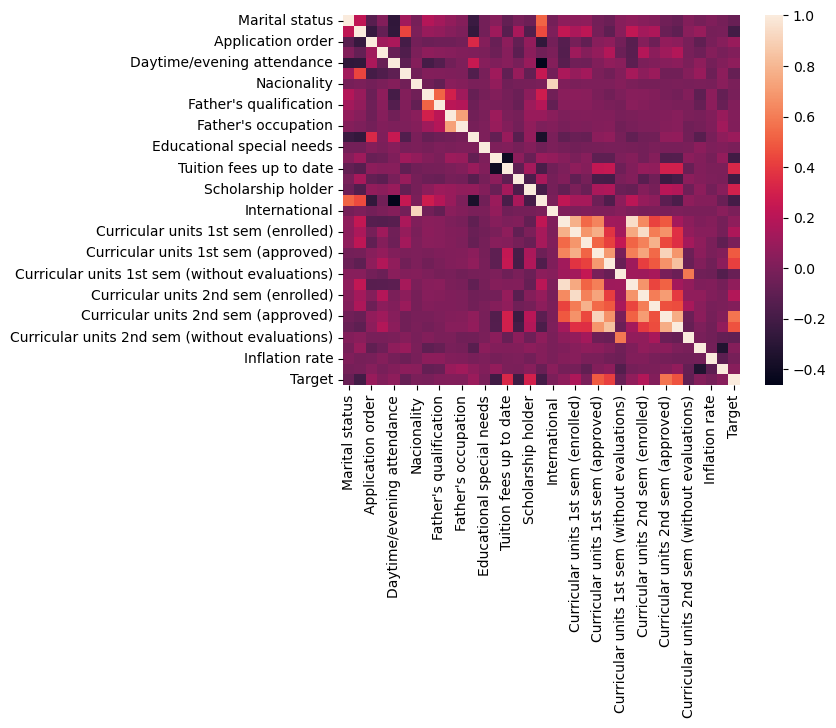

In [72]:
sns.heatmap(corr_matrix)

In [73]:
def correlation(data, threshold):
    corr_col_set = set()
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                column_name = corr_matrix.columns[j]
                corr_col_set.add(column_name)
                
    return corr_col_set

In [74]:
x_train.shape, x_test.shape

((3539, 34), (885, 34))

In [75]:
corr_column = correlation(x_train, 0.7)

In [76]:
x_train.drop(labels = corr_column, axis = 1, inplace = True)
x_test.drop(labels = corr_column, axis = 1, inplace = True)

/tmp/ipykernel_5389/449464841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train.drop(labels = corr_column, axis = 1, inplace = True)
/tmp/ipykernel_5389/449464841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test.drop(labels = corr_column, axis = 1, inplace = True)


In [77]:
x_train.shape, x_test.shape

((3539, 25), (885, 25))

In [78]:
x_train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1255,4,12,1,8,1,1,3,1,6,1,...,30,0,0,0,16,10.000000,0,11.1,0.6,2.02
3458,1,8,1,10,1,1,4,3,2,0,...,18,0,0,0,8,12.142857,0,16.2,0.3,-0.92
3390,1,8,1,16,1,1,23,28,10,0,...,18,0,0,0,7,12.285714,0,16.2,0.3,-0.92
1497,1,8,2,14,1,1,1,1,11,1,...,19,0,0,0,8,13.000000,0,15.5,2.8,-4.06
1536,1,12,1,12,1,1,22,14,9,1,...,27,0,0,0,14,0.000000,0,11.1,0.6,2.02


In [79]:
y_train.head()

1255    0
3458    1
3390    1
1497    1
1536    0
Name: Target, dtype: int64

In [80]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,1,4,1,12,1,3,22,27,8,1,...,27,0,0,0,8,14.414286,0,12.7,3.7,-1.70
4127,1,1,1,3,0,1,23,28,3,0,...,34,0,0,0,6,11.666667,0,10.8,1.4,1.74
1276,1,8,5,14,1,1,1,14,8,1,...,18,0,0,0,7,12.666667,0,11.1,0.6,2.02
1890,1,1,1,2,1,1,25,33,5,1,...,18,0,0,0,0,0.000000,0,11.1,0.6,2.02
624,1,8,4,5,1,1,23,27,10,0,...,23,0,0,0,8,12.666667,0,11.1,0.6,2.02


In [81]:
y_test.head()

2766    1
4127    1
1276    1
1890    1
624     0
Name: Target, dtype: int64

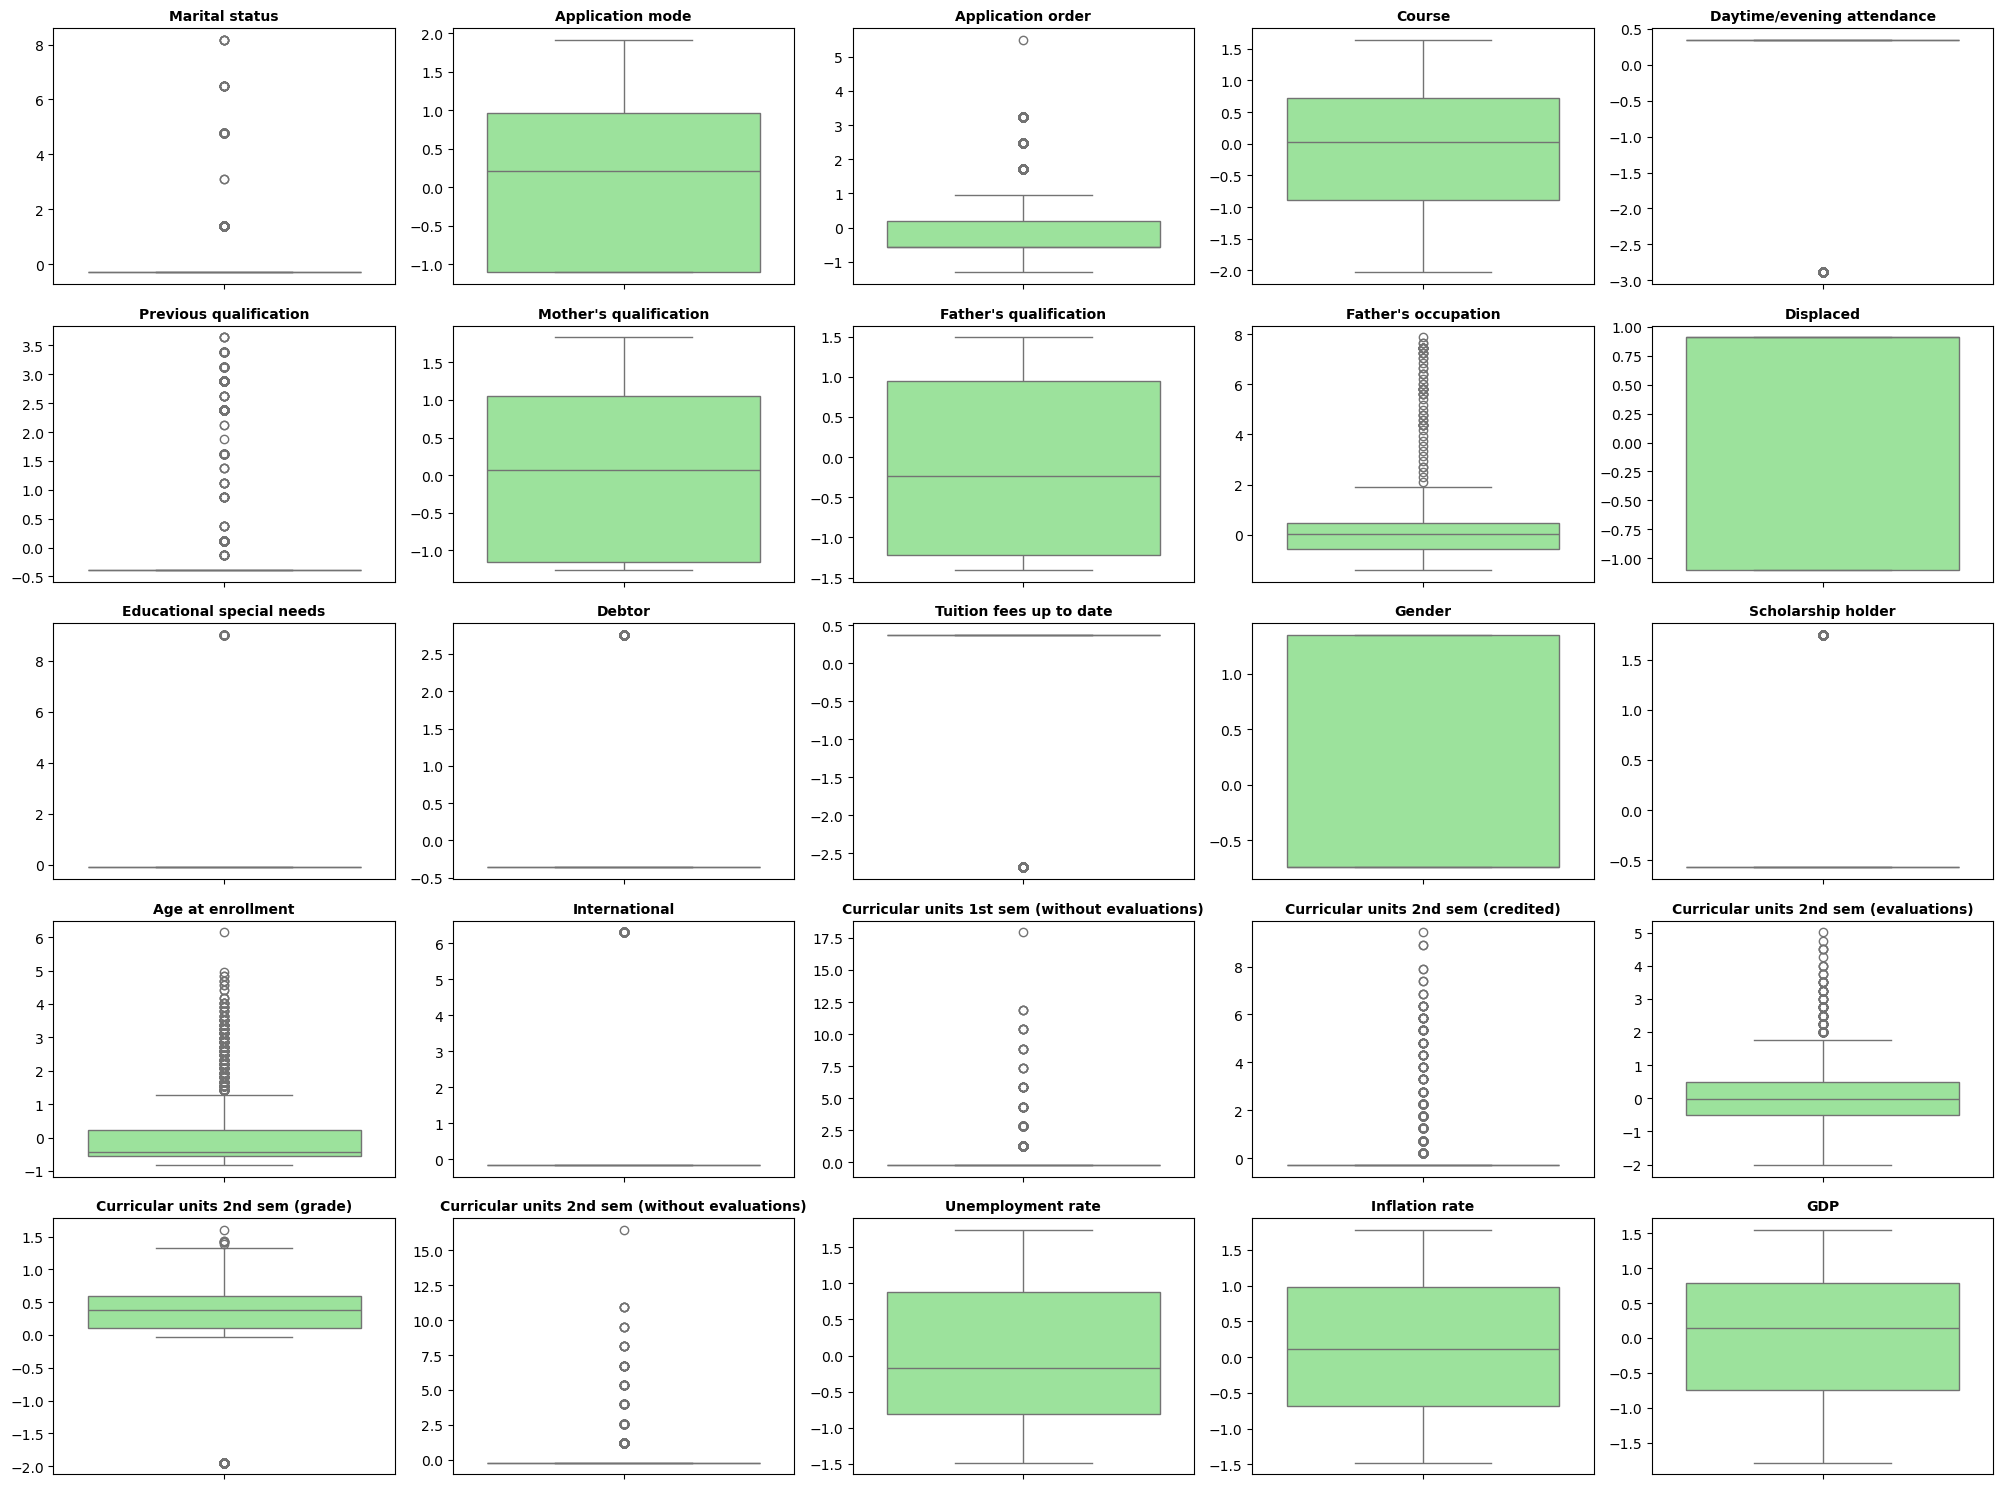

In [88]:
# Lấy danh sách toàn bộ 25 cột của x_train
columns = x_train.columns
n_cols = len(columns)

# Cài đặt lưới 5 cột, tính số hàng tương ứng (5 hàng)
grid_cols = 5
grid_rows = math.ceil(n_cols / grid_cols)

# Tạo một "bảng vẽ" siêu to khổng lồ
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 15))
axes = axes.flatten() # Trải phẳng lưới ra để dễ dùng vòng lặp for

# Vẽ boxplot cho từng cột
for i, col in enumerate(columns):
    # Vẽ dạng dọc (y=) cho gọn không gian
    sns.boxplot(y=x_train[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10, fontweight='bold') # Tên cột làm tiêu đề
    axes[i].set_ylabel('') # Xóa nhãn trục y cho đỡ vướng mắt

# Xóa các ô thừa (nếu tổng số cột không chia hết cho 5, dù bài này là chẵn 25)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()
plt.show()

In [89]:
# Danh sách ĐƯỢC PHÉP xóa outlier
target_columns = [
    'Age at enrollment',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (grade)'
]

# Copy ra một bản để tránh cảnh báo SettingWithCopyWarning của Pandas
x_train_clean = x_train.copy()
y_train_clean = y_train.copy()

for col in target_columns:
    # Tính Q1, Q3 và IQR cho từng cột
    Q1 = x_train_clean[col].quantile(0.25)
    Q3 = x_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc lấy các dòng hợp lệ
    valid_indices = (x_train_clean[col] >= lower_bound) & (x_train_clean[col] <= upper_bound)
    
    # Cập nhật lại tập dữ liệu (cắt bỏ outlier)
    x_train_clean = x_train_clean[valid_indices]
    y_train_clean = y_train_clean[valid_indices]

print(f"Số dòng ban đầu: {len(x_train)}")
print(f"Số dòng sau khi dọn rác: {len(x_train_clean)}")
print(f"Đã dọn dẹp {len(x_train) - len(x_train_clean)} sinh viên dị biệt!")

Số dòng ban đầu: 3539
Số dòng sau khi dọn rác: 2447
Đã dọn dẹp 1092 sinh viên dị biệt!


In [82]:
for col in  x_train.columns:
    col_mean = np.mean(x_train[col])
    col_std = np.std(x_train[col])
    
    x_train[col] = (x_train[col] - col_mean) / col_std
    x_test[col] = (x_test[col] - col_mean) / col_std

/tmp/ipykernel_5389/547317723.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[col] = (x_train[col] - col_mean) / col_std
/tmp/ipykernel_5389/547317723.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = (x_test[col] - col_mean) / col_std


In [83]:
x_train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1255,4.782061,0.972295,-0.554594,-0.425799,0.345807,-0.38899,-1.043386,-1.404812,-0.381149,0.907869,...,0.886227,-0.158754,-0.205774,-0.282285,1.994406,-0.036029,-0.198171,-0.170866,-0.462112,0.890018
3458,-0.294038,0.217369,-0.554594,0.033273,0.345807,-0.38899,-0.932758,-1.223937,-1.206786,-1.101480,...,-0.689634,-0.158754,-0.205774,-0.282285,-0.010053,0.372848,-0.198171,1.737282,-0.678657,-0.401328
3390,-0.294038,0.217369,-0.554594,1.410488,0.345807,-0.38899,1.169174,1.037005,0.444489,-1.101480,...,-0.689634,-0.158754,-0.205774,-0.282285,-0.260611,0.400107,-0.198171,1.737282,-0.678657,-0.401328
1497,-0.294038,0.217369,0.200875,0.951416,0.345807,-0.38899,-1.264642,-1.404812,0.650898,0.907869,...,-0.558312,-0.158754,-0.205774,-0.282285,-0.010053,0.536400,-0.198171,1.475379,1.125880,-1.780521
1536,-0.294038,0.972295,-0.554594,0.492344,0.345807,-0.38899,1.058546,-0.229122,0.238079,0.907869,...,0.492262,-0.158754,-0.205774,-0.282285,1.493292,-1.944126,-0.198171,-0.170866,-0.462112,0.890018


In [84]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,-0.294038,-0.537557,-0.554594,0.492344,0.345807,0.114258,1.058546,0.946568,0.031670,0.907869,...,0.492262,-0.158754,-0.205774,-0.282285,-0.010053,0.806259,-0.198171,0.427768,1.775514,-0.743930
4127,-0.294038,-1.103751,-0.554594,-1.573478,-2.891787,-0.388990,1.169174,1.037005,-1.000377,-1.101480,...,1.411514,-0.158754,-0.205774,-0.282285,-0.511168,0.281987,-0.198171,-0.283110,0.115339,0.767032
1276,-0.294038,0.217369,2.467282,0.951416,0.345807,-0.388990,-1.264642,-0.229122,0.031670,0.907869,...,-0.689634,-0.158754,-0.205774,-0.282285,-0.260611,0.472796,-0.198171,-0.170866,-0.462112,0.890018
1890,-0.294038,-1.103751,-0.554594,-1.803014,0.345807,-0.388990,1.390430,1.489194,-0.587558,0.907869,...,-0.689634,-0.158754,-0.205774,-0.282285,-2.014513,-1.944126,-0.198171,-0.170866,-0.462112,0.890018
624,-0.294038,0.217369,1.711813,-1.114407,0.345807,-0.388990,1.169174,0.946568,0.444489,-1.101480,...,-0.033025,-0.158754,-0.205774,-0.282285,-0.010053,0.472796,-0.198171,-0.170866,-0.462112,0.890018
